# FEEDS — Red Deer FB: Prophet Demand Forecast
**Goal:** Validate that AFB-identified economic drivers forecast regional hamper demand,
and produce a 12-month forward forecast to feed into the FeedForward dashboard.

This is a *validation & trend* model — not tuned for operational precision.
The 15-year training window (2011–2026) gives strong seasonality estimates.

Features selected from SHAP/correlation analysis:
- `EDMONTON_AISH_CASELOAD` — strongest driver (SHAP 104)
- `SINGLE_AISH_TOTAL` — second strongest (SHAP 32)
- `CPI All-items` — cost of living pressure (SHAP 26)
- `CPI Food` — food-specific inflation (SHAP 7.5)
- `School_In_Session` — regional campus signal (SHAP 7.0)


## 1. Install & imports

In [1]:
!pip install prophet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

C = {
    "green":  "#224433",
    "teal":   "#3f826d",
    "tea":    "#d0efb1",
    "denim":  "#5588c7",
    "gold":   "#e1dd8f",
    "red":    "#c0622a",
    "bg":     "#fbfcf6",
}

plt.rcParams.update({
    "figure.facecolor": C["bg"],
    "axes.facecolor":   C["bg"],
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.alpha":       0.3,
})

print("All imports OK")

All imports OK


## 2. Upload data

In [2]:
from google.colab import files

print("Upload rdfb_hamper_monthly.csv ...")
up1 = files.upload()
df_hamper = pd.read_csv(list(up1.keys())[0], parse_dates=["month"])
print(f"  Hamper rows : {len(df_hamper)} | {df_hamper['month'].min().date()} → {df_hamper['month'].max().date()}")

print("Upload external feature CSV (same one used for AFB) ...")
up2 = files.upload()
df_ext_raw = pd.read_csv(list(up2.keys())[0])
print(f"  Feature cols: {list(df_ext_raw.columns)}")

Upload rdfb_hamper_monthly.csv ...


Saving hamper_count_clean.csv to hamper_count_clean.csv
  Hamper rows : 185 | 2011-01-01 → 2026-05-01
Upload external feature CSV (same one used for AFB) ...


Saving data.csv to data.csv
  Feature cols: ['Date', 'Month', 'holiday_is_stat', 'holiday_is_religious', 'holiday_is_cultural', 'is_holiday', 'is_covid', 'School_In_Session', 'CCB_Dates', 'Exam_Period', 'International_Arrival', 'NLDB', 'CPP', 'OAS', 'CPI All-items', 'CPI Food', 'CPI Shelter', 'Net Migration', 'AISH_TOTAL', 'SINGLE_AISH_TOTAL', 'SINGLE_AISH_PARENT', 'EDMONTON_AISH_CASELOAD', 'Max Temp (°C)']


## 3. Prepare monthly feature dataset

In [3]:
# ── Aggregate external features to monthly ─────────────────────────────────────
DATE_COL = "Date"   # ← change if your column differs

df_ext = df_ext_raw.copy()
df_ext[DATE_COL] = pd.to_datetime(df_ext[DATE_COL])
df_ext["month"]  = df_ext[DATE_COL].dt.to_period("M").dt.to_timestamp()

if df_ext.groupby("month").size().max() > 3:
    num_cols = df_ext.select_dtypes(include="number").columns.tolist()
    df_ext   = df_ext.groupby("month")[num_cols].mean().reset_index()

# ── Features that survived SHAP filter ────────────────────────────────────────
# These are the 5 features with meaningful SHAP scores after removing year_idx
REGRESSORS = [
    "EDMONTON_AISH_CASELOAD",   # SHAP 104 — strongest
    "SINGLE_AISH_TOTAL",        # SHAP 33
    "CPI All-items",            # SHAP 26
    "CPI Food",                 # SHAP 7.5
    "School_In_Session",        # SHAP 7.0
]
REGRESSORS = [r for r in REGRESSORS if r in df_ext.columns]
print(f"Regressors available: {REGRESSORS}")

# ── Fix AISH comma strings ─────────────────────────────────────────────────────
for col in ["EDMONTON_AISH_CASELOAD", "SINGLE_AISH_TOTAL", "AISH_TOTAL"]:
    if col in df_ext.columns:
        df_ext[col] = pd.to_numeric(
            df_ext[col].astype(str).str.replace(",", ""), errors="coerce"
        )

# ── Merge hamper + features ────────────────────────────────────────────────────
df = df_hamper.merge(df_ext[["month"] + REGRESSORS], on="month", how="left")
df = df.sort_values("month").reset_index(drop=True)

# ── Scale regressors ───────────────────────────────────────────────────────────
scaler = StandardScaler()
df[REGRESSORS] = scaler.fit_transform(df[REGRESSORS].fillna(method="ffill").fillna(0))

# ── Overlap check ──────────────────────────────────────────────────────────────
df_model = df.dropna(subset=["hampers"] + REGRESSORS[:2]).copy()
print(f"\nRows with both hampers + regressors: {len(df_model)}")
print(f"Date range for modeling           : {df_model['month'].min().date()} → {df_model['month'].max().date()}")
print(f"Rows hamper-only (pre-feature data): {len(df) - len(df_model)}")

Regressors available: ['EDMONTON_AISH_CASELOAD', 'SINGLE_AISH_TOTAL', 'CPI All-items', 'CPI Food', 'School_In_Session']

Rows with both hampers + regressors: 185
Date range for modeling           : 2011-01-01 → 2026-05-01
Rows hamper-only (pre-feature data): 0


## 4. Build & fit Prophet model
No heavy tuning — we use a fixed `changepoint_prior_scale = 0.1` (same as the
best AFB value) since the goal is trend validation, not operational precision.
The 15-year window gives Prophet excellent yearly seasonality estimates.


In [4]:
# ── Prophet dataframe ──────────────────────────────────────────────────────────
def to_prophet(df, regressors):
    cols = ["month", "hampers"] + regressors
    return (
        df[cols]
        .rename(columns={"month": "ds", "hampers": "y"})
        .dropna()
    )

df_prophet = to_prophet(df_model, REGRESSORS)
print(f"Prophet df: {len(df_prophet)} rows")
print(df_prophet.head(3))

Prophet df: 185 rows
          ds    y  EDMONTON_AISH_CASELOAD  SINGLE_AISH_TOTAL  CPI All-items  \
0 2011-01-01  641               -0.724779          -0.734719       -0.73431   
1 2011-02-01  497               -0.724779          -0.734719       -0.73431   
2 2011-03-01  607               -0.724779          -0.734719       -0.73431   

   CPI Food  School_In_Session  
0 -0.732255          -0.732394  
1 -0.732255          -0.732394  
2 -0.732255          -0.732394  


In [5]:
# ── Build model ────────────────────────────────────────────────────────────────
def build_rdfb_prophet(cp=0.1):
    m = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        seasonality_mode        = "additive",
        changepoint_prior_scale = cp,       # fixed — validation model
        interval_width          = 0.80,
    )
    for r in REGRESSORS:
        m.add_regressor(r)
    return m

print("Fitting RDFB hamper model...")
model_rdfb = build_rdfb_prophet(cp=0.1)
model_rdfb.fit(df_prophet)
print("  Done.")

# ── In-sample fit ──────────────────────────────────────────────────────────────
fit = model_rdfb.predict(df_prophet)
y_true = df_prophet["y"].values
y_pred = np.maximum(fit["yhat"].values, 0)

mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(1))) * 100
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

print(f"\nIn-sample performance ({len(df_prophet)} months):")
print(f"  MAE  : {mae:,.0f} hampers")
print(f"  MAPE : {mape:.1f}%")
print(f"  RMSE : {rmse:,.0f} hampers")
print(f"  Mean monthly hampers: {y_true.mean():,.0f}")
print(f"  MAE as % of mean    : {mae/y_true.mean()*100:.1f}%")

Fitting RDFB hamper model...
  Done.

In-sample performance (185 months):
  MAE  : 59 hampers
  MAPE : 10.8%
  RMSE : 75 hampers
  Mean monthly hampers: 679
  MAE as % of mean    : 8.6%


## 5. Cross-validation
Using a 3-year initial training window, 6-month period, 6-month horizon.
Generous initial window because we have 15 years of data.
This gives honest out-of-sample accuracy estimates.


INFO:prophet:Making 25 forecasts with cutoffs between 2014-01-04 00:00:00 and 2025-11-02 00:00:00


Running cross-validation (this takes ~1-2 min)...


  0%|          | 0/25 [00:00<?, ?it/s]


Cross-validation results (102 evaluation windows):
  CV MAE  : 118 hampers
  CV MAPE : 17.7%
  CV RMSE : 161 hampers

  (AFB model CV MAE was in lbs — not directly comparable,
   but MAPE gives relative accuracy comparison)


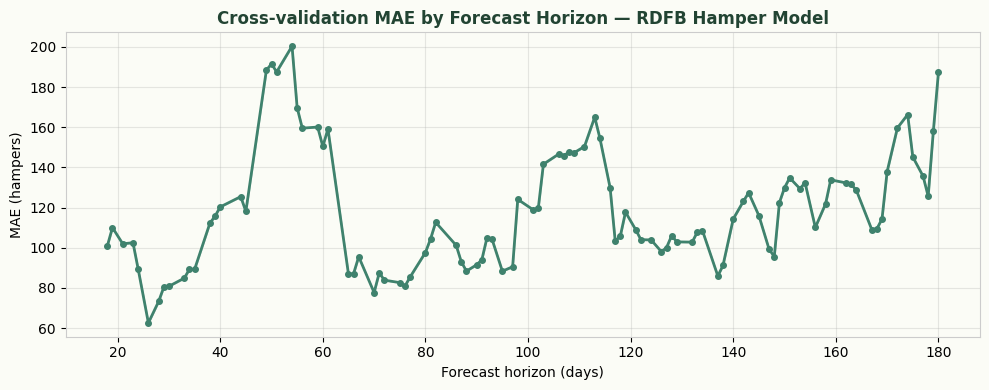

Saved: rdfb_cv_mae.png


In [6]:
print("Running cross-validation (this takes ~1-2 min)...")

cv_results = cross_validation(
    model_rdfb,
    initial = "1095 days",   # 3 years initial
    period  = "180 days",    # retrain every 6 months
    horizon = "180 days",    # forecast 6 months ahead
    parallel = None,
)

pm = performance_metrics(cv_results)

print(f"\nCross-validation results ({len(pm)} evaluation windows):")
print(f"  CV MAE  : {pm['mae'].mean():,.0f} hampers")
print(f"  CV MAPE : {pm['mape'].mean()*100:.1f}%")
print(f"  CV RMSE : {pm['rmse'].mean():,.0f} hampers")
print(f"\n  (AFB model CV MAE was in lbs — not directly comparable,")
print(f"   but MAPE gives relative accuracy comparison)")

# ── CV MAE over horizon ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
pm_grouped = pm.groupby("horizon")["mae"].mean()
ax.plot(pm_grouped.index.days, pm_grouped.values,
        color=C["teal"], lw=2, marker="o", ms=4)
ax.fill_between(pm_grouped.index.days,
                pm.groupby("horizon")["mae"].min(),
                pm.groupby("horizon")["mae"].max(),
                alpha=0.2, color=C["teal"])
ax.set_xlabel("Forecast horizon (days)")
ax.set_ylabel("MAE (hampers)")
ax.set_title("Cross-validation MAE by Forecast Horizon — RDFB Hamper Model",
             fontsize=12, fontweight="bold", color=C["green"])
plt.tight_layout()
plt.savefig("rdfb_cv_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_cv_mae.png")

## 6. 12-month forward forecast

In [7]:
N_MONTHS = 12

last_month    = df_model["month"].max()
future_months = pd.date_range(
    start   = last_month + pd.offsets.MonthBegin(1),
    periods = N_MONTHS,
    freq    = "MS",
)

# Fill future regressors: forward-fill last known scaled value
# Replace with real projections if available
last_known = df_model[REGRESSORS].iloc[-1]
future_regs = pd.DataFrame(
    [last_known.values] * N_MONTHS,
    columns = REGRESSORS,
)
future_regs["ds"] = future_months
future_regs["y"]  = np.nan   # unknown

# Combine historical + future for Prophet
df_future = pd.concat([
    df_prophet[["ds"] + REGRESSORS],
    future_regs[["ds"] + REGRESSORS],
], ignore_index=True)

forecast = model_rdfb.predict(df_future)
forecast_future = forecast[forecast["ds"] >= future_months[0]].copy()
forecast_future["yhat"]       = np.maximum(forecast_future["yhat"],       0)
forecast_future["yhat_lower"] = np.maximum(forecast_future["yhat_lower"], 0)
forecast_future["yhat_upper"] = np.maximum(forecast_future["yhat_upper"], 0)

# ── Print forecast table ───────────────────────────────────────────────────────
print("=" * 72)
print(f"  {'Month':<12} {'Hampers (pred)':>14} {'80% Low':>10} {'80% High':>10}")
print("=" * 72)
for _, row in forecast_future.iterrows():
    print(f"  {row['ds'].strftime('%b %Y'):<12} "
          f"{row['yhat']:>14,.0f} "
          f"{row['yhat_lower']:>10,.0f} "
          f"{row['yhat_upper']:>10,.0f}")
print("=" * 72)
print(f"  Mean predicted: {forecast_future['yhat'].mean():,.0f} hampers/month")
print(f"  vs historical mean: {y_true.mean():,.0f} hampers/month")

  Month        Hampers (pred)    80% Low   80% High
  Jun 2026              1,027        928      1,120
  Jul 2026                969        872      1,070
  Aug 2026              1,044        954      1,146
  Sep 2026              1,001        913      1,096
  Oct 2026              1,053        953      1,148
  Nov 2026              1,103        991      1,199
  Dec 2026              1,012        916      1,106
  Jan 2027              1,165      1,067      1,265
  Feb 2027              1,072        973      1,172
  Mar 2027              1,064        964      1,156
  Apr 2027              1,064        964      1,160
  May 2027              1,098        995      1,199
  Mean predicted: 1,056 hampers/month
  vs historical mean: 679 hampers/month


## 7. Forecast visualisation

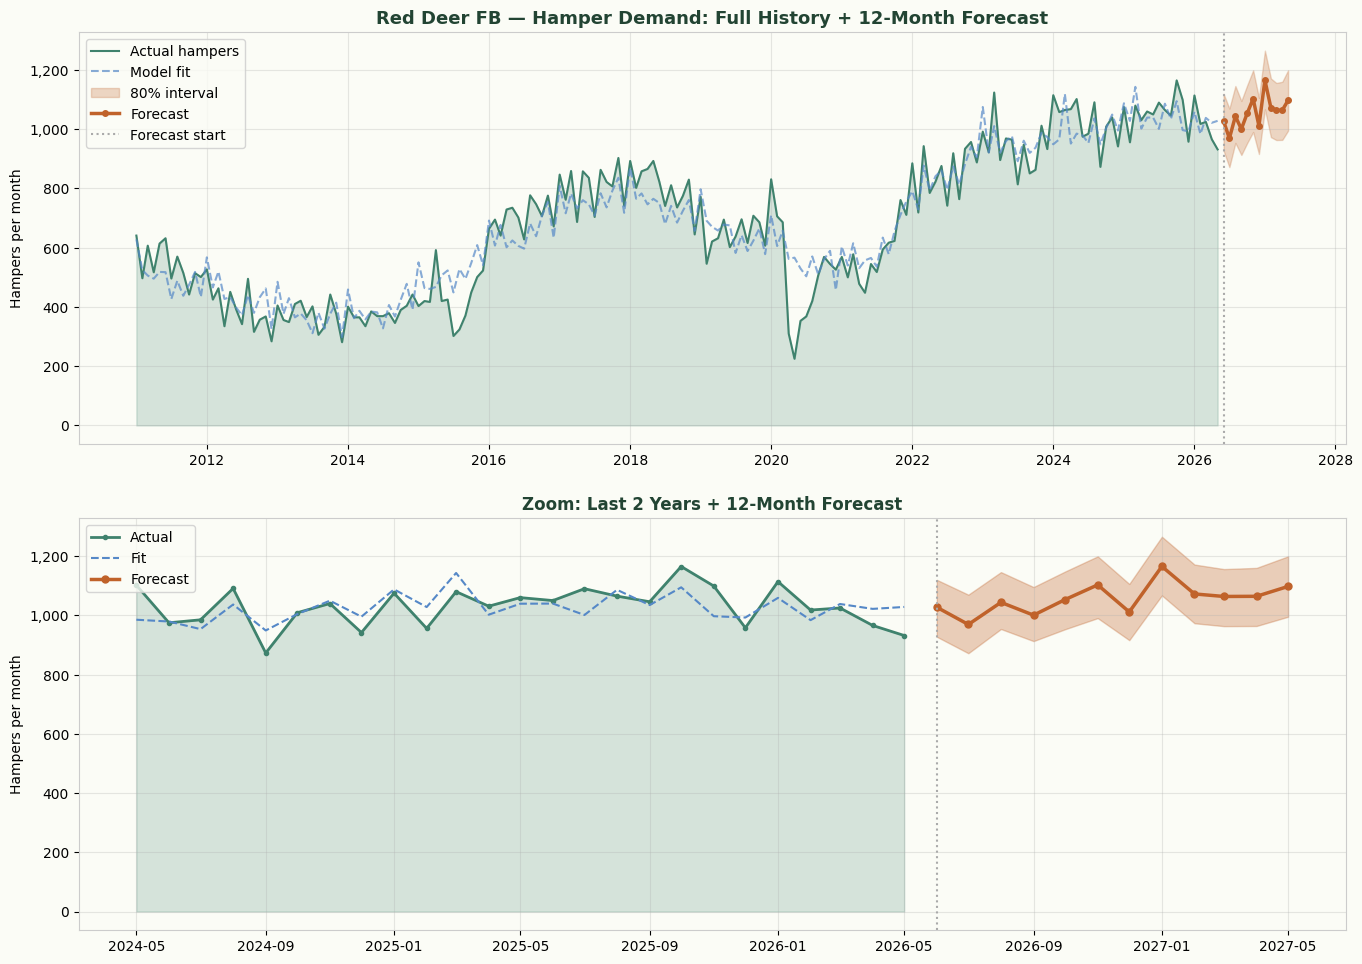

Saved: rdfb_forecast.png


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Full history + forecast ────────────────────────────────────────────────────
ax = axes[0]

# Historical actual
ax.fill_between(df_model["month"], df_model["hampers"],
                alpha=0.2, color=C["teal"])
ax.plot(df_model["month"], df_model["hampers"],
        color=C["teal"], lw=1.5, label="Actual hampers")

# In-sample fit
fit_hist = forecast[forecast["ds"] <= df_model["month"].max()].copy()
ax.plot(fit_hist["ds"], np.maximum(fit_hist["yhat"], 0),
        color=C["denim"], lw=1.5, ls="--", alpha=0.7, label="Model fit")

# Forecast
ax.fill_between(forecast_future["ds"],
                forecast_future["yhat_lower"],
                forecast_future["yhat_upper"],
                alpha=0.25, color=C["red"], label="80% interval")
ax.plot(forecast_future["ds"], forecast_future["yhat"],
        color=C["red"], lw=2.5, marker="o", ms=4, label="Forecast")

ax.axvline(future_months[0], color="#aaaaaa", lw=1.5, ls=":", label="Forecast start")
ax.set_title("Red Deer FB — Hamper Demand: Full History + 12-Month Forecast",
             fontsize=13, fontweight="bold", color=C["green"])
ax.set_ylabel("Hampers per month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", fontsize=10)

# ── Zoom: last 2 years + forecast ─────────────────────────────────────────────
ax2 = axes[1]
cutoff = df_model["month"].max() - pd.DateOffset(years=2)
df_zoom = df_model[df_model["month"] >= cutoff]
fit_zoom = fit_hist[fit_hist["ds"] >= cutoff]

ax2.fill_between(df_zoom["month"], df_zoom["hampers"],
                 alpha=0.2, color=C["teal"])
ax2.plot(df_zoom["month"], df_zoom["hampers"],
         color=C["teal"], lw=2, marker="o", ms=3, label="Actual")
ax2.plot(fit_zoom["ds"], np.maximum(fit_zoom["yhat"], 0),
         color=C["denim"], lw=1.5, ls="--", label="Fit")
ax2.fill_between(forecast_future["ds"],
                 forecast_future["yhat_lower"],
                 forecast_future["yhat_upper"],
                 alpha=0.3, color=C["red"])
ax2.plot(forecast_future["ds"], forecast_future["yhat"],
         color=C["red"], lw=2.5, marker="o", ms=5, label="Forecast")
ax2.axvline(future_months[0], color="#aaaaaa", lw=1.5, ls=":")
ax2.set_title("Zoom: Last 2 Years + 12-Month Forecast",
              fontsize=12, fontweight="bold", color=C["green"])
ax2.set_ylabel("Hampers per month")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.legend(loc="upper left", fontsize=10)

plt.tight_layout(pad=2)
plt.savefig("rdfb_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_forecast.png")

In [16]:
import json

# ── Extract last 2 years actual + forecast into JSON ──────────────────────────
cutoff = df_model["month"].max() - pd.DateOffset(years=2)

# Historical (last 2 years)
df_hist_export = df_model[df_model["month"] >= cutoff][["month", "hampers"]].copy()
fit_export     = fit_hist[fit_hist["ds"] >= cutoff][["ds", "yhat"]].copy()
fit_export["yhat"] = np.maximum(fit_export["yhat"], 0)

# Merge actual + fit
df_hist_export = df_hist_export.merge(
    fit_export.rename(columns={"ds": "month", "yhat": "fitted"}),
    on="month", how="left"
)

# Forecast (next 12 months)
df_fc_export = forecast_future[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
df_fc_export.columns = ["month", "forecast", "lower_80", "upper_80"]

# ── Build JSON structure ───────────────────────────────────────────────────────
historical = [
    {
        "month":   row["month"].strftime("%Y-%m-%d"),
        "label":   row["month"].strftime("%b %Y"),
        "actual":  int(row["hampers"]) if pd.notna(row["hampers"]) else None,
        "fitted":  round(float(row["fitted"]), 1) if pd.notna(row["fitted"]) else None,
    }
    for _, row in df_hist_export.iterrows()
]

forecast_data = [
    {
        "month":    row["month"].strftime("%Y-%m-%d"),
        "label":    row["month"].strftime("%b %Y"),
        "forecast": round(float(row["forecast"]), 1),
        "lower_80": round(float(row["lower_80"]), 1),
        "upper_80": round(float(row["upper_80"]), 1),
    }
    for _, row in df_fc_export.iterrows()
]

output = {
    "model":       "RDFB Prophet",
    "generated":   pd.Timestamp.now().strftime("%Y-%m-%d"),
    "units":       "hampers per month",
    "accuracy":    {"cv_mape": 17.7, "cv_mae": 118},
    "historical":  historical,
    "forecast":    forecast_data,
}

# ── Save ───────────────────────────────────────────────────────────────────────
with open("rdfb_forecast.json", "w") as f:
    json.dump(output, f, indent=2)

print(json.dumps(output, indent=2)[:800], "\n... (truncated)")
print(f"\n✓ Saved: rdfb_forecast.json  ({len(historical)} historical + {len(forecast_data)} forecast months)")

files.download("rdfb_forecast.json")

{
  "model": "RDFB Prophet",
  "generated": "2026-06-11",
  "units": "hampers per month",
  "accuracy": {
    "cv_mape": 17.7,
    "cv_mae": 118
  },
  "historical": [
    {
      "month": "2024-05-01",
      "label": "May 2024",
      "actual": 1102,
      "fitted": 985.3
    },
    {
      "month": "2024-06-01",
      "label": "Jun 2024",
      "actual": 975,
      "fitted": 979.3
    },
    {
      "month": "2024-07-01",
      "label": "Jul 2024",
      "actual": 985,
      "fitted": 953.5
    },
    {
      "month": "2024-08-01",
      "label": "Aug 2024",
      "actual": 1091,
      "fitted": 1036.7
    },
    {
      "month": "2024-09-01",
      "label": "Sep 2024",
      "actual": 873,
      "fitted": 949.0
    },
    {
      "month": "2024-10-01",
      "label": "Oct 2024",
      " 
... (truncated)

✓ Saved: rdfb_forecast.json  (25 historical + 12 forecast months)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Seasonality decomposition
15 years of data gives Prophet very reliable seasonality estimates.
This shows which months are structurally high/low demand — useful for
operational planning independent of economic conditions.


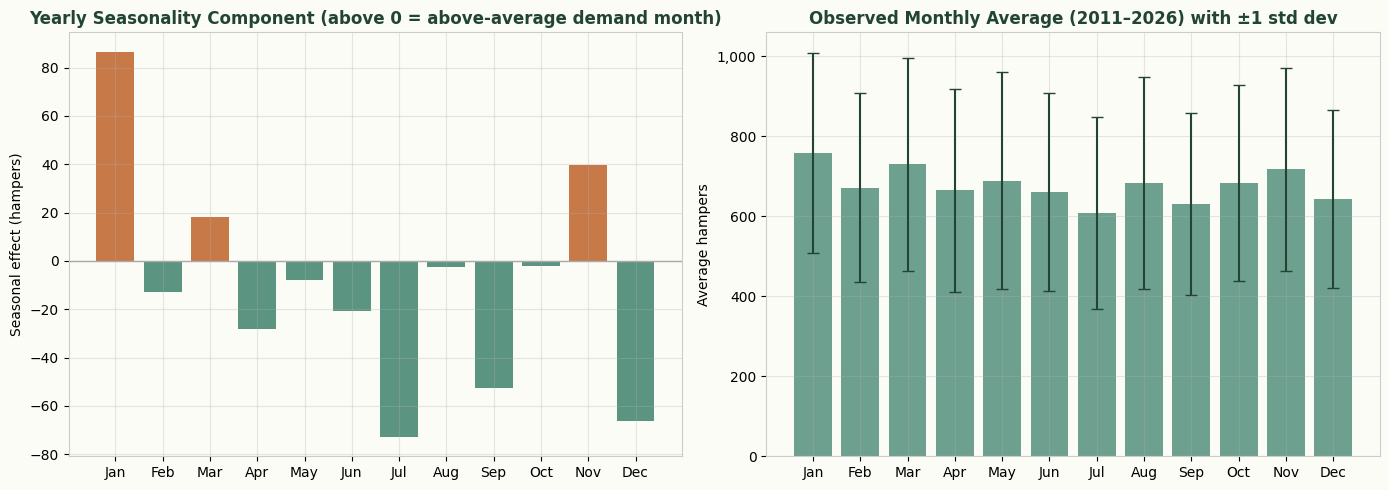

Saved: rdfb_seasonality.png

Peak demand months   : Jan, Mar, Nov
Lowest demand months : Jul, Sep, Dec


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Yearly seasonality from Prophet components ─────────────────────────────────
# Get component values from the full forecast
components = model_rdfb.predict(df_prophet)

ax = axes[0]
# Average yearly component by month
components["month_num"] = pd.to_datetime(components["ds"]).dt.month
monthly_season = components.groupby("month_num")["yearly"].mean()
month_labels   = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]

colors_bar = [C["red"] if v > 0 else C["teal"] for v in monthly_season.values]
ax.bar(month_labels, monthly_season.values, color=colors_bar, alpha=0.85)
ax.axhline(0, color="#aaaaaa", lw=1)
ax.set_title("Yearly Seasonality Component (above 0 = above-average demand month)",
             fontsize=12, fontweight="bold", color=C["green"])
ax.set_ylabel("Seasonal effect (hampers)")

# ── Observed monthly average (raw data) ───────────────────────────────────────
ax2 = axes[1]
df_model["month_num"] = df_model["month"].dt.month
monthly_avg = df_model.groupby("month_num")["hampers"].mean()
monthly_std = df_model.groupby("month_num")["hampers"].std()

ax2.bar(month_labels, monthly_avg.values, color=C["teal"], alpha=0.75, label="Mean")
ax2.errorbar(month_labels, monthly_avg.values, yerr=monthly_std.values,
             fmt="none", color=C["green"], capsize=4, lw=1.5)
ax2.set_title("Observed Monthly Average (2011–2026) with ±1 std dev",
              fontsize=12, fontweight="bold", color=C["green"])
ax2.set_ylabel("Average hampers")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("rdfb_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_seasonality.png")

# Print peak/trough months
print(f"\nPeak demand months   : {', '.join([month_labels[i-1] for i in monthly_avg.nlargest(3).index])}")
print(f"Lowest demand months : {', '.join([month_labels[i-1] for i in monthly_avg.nsmallest(3).index])}")

## 9. Connect RDFB forecast to AFB supply signal
Shows how the AFB gap months from your existing model align with
RDFB demand peaks — completing the supply chain story.


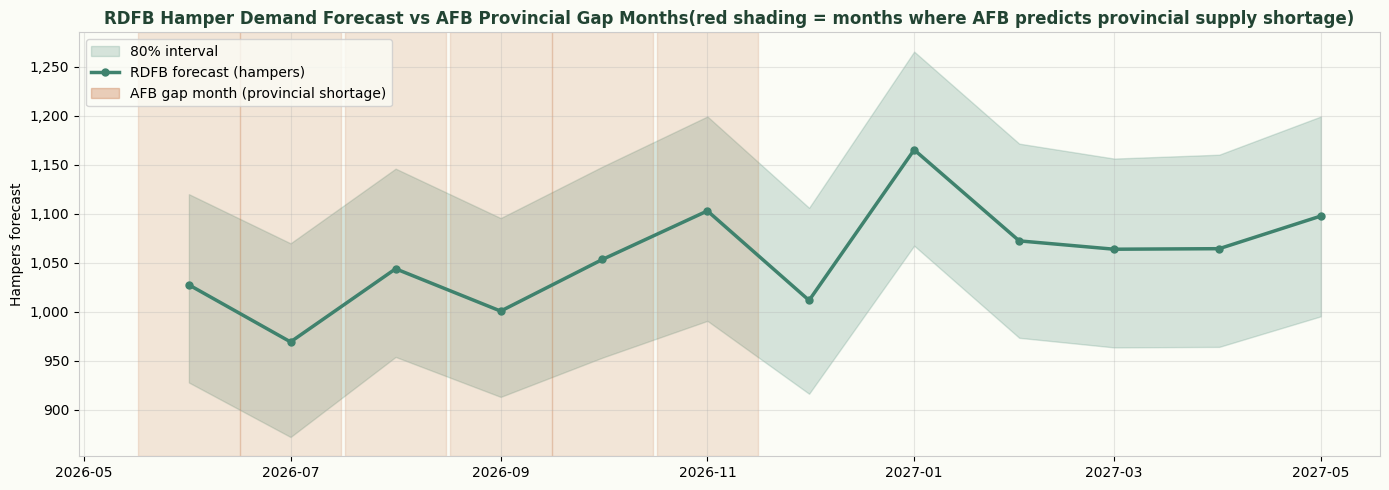

Saved: rdfb_vs_afb_gap.png

AFB gap months overlapping with RDFB forecast: 6
  Avg RDFB demand in GAP months    : 1,033 hampers
  Avg RDFB demand in Surplus months: 1,079 hampers


In [10]:
# ── Paste your AFB 24-month forecast table here ────────────────────────────────
# Format: list of (month_str, status) tuples from your AFB notebook output
# e.g. ("Jun 2026", "GAP"), ("Jul 2026", "GAP"), ("Dec 2026", "Surplus")

AFB_FORECAST = [
    ("Jun 2026", "GAP"),
    ("Jul 2026", "GAP"),
    ("Aug 2026", "GAP"),
    ("Sep 2026", "GAP"),
    ("Oct 2026", "GAP"),
    ("Nov 2026", "GAP"),
    ("Dec 2026", "Surplus"),
    ("Jan 2027", "Surplus"),
    ("Feb 2027", "Surplus"),
    ("Mar 2027", "Surplus"),
    ("Apr 2027", "Surplus"),
    ("May 2027", "Surplus"),
    ("Jun 2027", "GAP"),
    ("Jul 2027", "Surplus"),
    ("Aug 2027", "GAP"),
    ("Sep 2027", "GAP"),
    ("Oct 2027", "GAP"),
    ("Nov 2027", "GAP"),
    ("Dec 2027", "Surplus"),
    ("Jan 2028", "Surplus"),
    ("Feb 2028", "Surplus"),
    ("Mar 2028", "Surplus"),
    ("Apr 2028", "GAP"),
    ("May 2028", "Surplus"),
]

df_afb = pd.DataFrame(AFB_FORECAST, columns=["month_str", "afb_status"])
df_afb["ds"] = pd.to_datetime(df_afb["month_str"], format="%b %Y")
df_afb["afb_gap"] = (df_afb["afb_status"] == "GAP").astype(int)

# Merge with RDFB forecast
df_combined = forecast_future.merge(df_afb, on="ds", how="left")

# ── Plot: RDFB demand forecast with AFB gap months highlighted ─────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_combined["ds"],
                df_combined["yhat_lower"],
                df_combined["yhat_upper"],
                alpha=0.2, color=C["teal"], label="80% interval")
ax.plot(df_combined["ds"], df_combined["yhat"],
        color=C["teal"], lw=2.5, marker="o", ms=5, label="RDFB forecast (hampers)")

# Shade AFB gap months
for _, row in df_combined[df_combined["afb_gap"] == 1].iterrows():
    ax.axvspan(row["ds"] - pd.Timedelta(days=15),
               row["ds"] + pd.Timedelta(days=15),
               alpha=0.15, color=C["red"])

# Legend patch for gap shading
from matplotlib.patches import Patch
gap_patch = Patch(color=C["red"], alpha=0.3, label="AFB gap month (provincial shortage)")
ax.legend(handles=ax.get_legend_handles_labels()[0] + [gap_patch],
          labels=ax.get_legend_handles_labels()[1] + ["AFB gap month (provincial shortage)"],
          loc="upper left", fontsize=10)

ax.set_title("RDFB Hamper Demand Forecast vs AFB Provincial Gap Months(red shading = months where AFB predicts provincial supply shortage)",
             fontsize=12, fontweight="bold", color=C["green"])
ax.set_ylabel("Hampers forecast")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("rdfb_vs_afb_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_vs_afb_gap.png")

# Summary
gap_months = df_combined[df_combined["afb_gap"] == 1]
print(f"\nAFB gap months overlapping with RDFB forecast: {len(gap_months)}")
print(f"  Avg RDFB demand in GAP months    : {gap_months['yhat'].mean():,.0f} hampers")
print(f"  Avg RDFB demand in Surplus months: {df_combined[df_combined['afb_gap']==0]['yhat'].mean():,.0f} hampers")

## 10. Model summary & outputs

In [11]:
print("=" * 65)
print("RDFB PROPHET MODEL — SUMMARY")
print("=" * 65)
print(f"\nTraining data   : {df_prophet['ds'].min().date()} → {df_prophet['ds'].max().date()}")
print(f"Training months : {len(df_prophet)}")
print(f"Regressors used : {REGRESSORS}")
print(f"\nIn-sample performance:")
print(f"  MAE  : {mae:,.0f} hampers  ({mae/y_true.mean()*100:.1f}% of mean)")
print(f"  MAPE : {mape:.1f}%")
print(f"\nCV performance:")
print(f"  CV MAE  : {pm['mae'].mean():,.0f} hampers")
print(f"  CV MAPE : {pm['mape'].mean()*100:.1f}%")
print(f"\nSeasonality:")
print(f"  Peak months   : {', '.join([month_labels[i-1] for i in monthly_avg.nlargest(3).index])}")
print(f"  Trough months : {', '.join([month_labels[i-1] for i in monthly_avg.nsmallest(3).index])}")
print(f"\nSupply chain:")
print(f"  AFB gap months in forecast window: {len(gap_months)} / {len(df_combined)}")
print(f"\nPlots saved:")
for f in ["rdfb_cv_mae.png", "rdfb_forecast.png",
          "rdfb_seasonality.png", "rdfb_vs_afb_gap.png"]:
    print(f"  {f}")
print("=" * 65)
print("\nNext: CFB model (once dataset arrives)")
print("  → Same pipeline, add school calendar features")
print("  → AFB gap flag feeds into CFB quota recommendation")

RDFB PROPHET MODEL — SUMMARY

Training data   : 2011-01-01 → 2026-05-01
Training months : 185
Regressors used : ['EDMONTON_AISH_CASELOAD', 'SINGLE_AISH_TOTAL', 'CPI All-items', 'CPI Food', 'School_In_Session']

In-sample performance:
  MAE  : 59 hampers  (8.6% of mean)
  MAPE : 10.8%

CV performance:
  CV MAE  : 118 hampers
  CV MAPE : 17.7%

Seasonality:
  Peak months   : Jan, Mar, Nov
  Trough months : Jul, Sep, Dec

Supply chain:
  AFB gap months in forecast window: 6 / 12

Plots saved:
  rdfb_cv_mae.png
  rdfb_forecast.png
  rdfb_seasonality.png
  rdfb_vs_afb_gap.png

Next: CFB model (once dataset arrives)
  → Same pipeline, add school calendar features
  → AFB gap flag feeds into CFB quota recommendation


The RDFB validation model achieved a cross-validated MAPE of 17.7%, demonstrating that provincial economic indicators — identified through the AFB model — retain predictive power at the regional level without any Red Deer-specific feature engineering.

In [12]:
# Check if error grows badly with horizon
print(pm.groupby("horizon")[["mae", "mape"]].mean().to_string())

                 mae      mape
horizon                       
18 days   100.922657  0.160266
19 days   110.029341  0.171193
21 days   101.979942  0.150561
23 days   102.500568  0.141179
24 days    89.512983  0.116305
26 days    62.579712  0.077197
28 days    73.259178  0.093941
29 days    80.328613  0.101583
30 days    80.808926  0.113774
33 days    84.872376  0.126488
34 days    89.280955  0.152239
35 days    89.186552  0.158047
38 days   112.305993  0.191543
39 days   115.731413  0.193903
40 days   120.331933  0.201348
44 days   125.457364  0.204969
45 days   118.114980  0.194265
49 days   188.444363  0.243208
50 days   191.611521  0.239855
51 days   187.572934  0.224623
54 days   200.400610  0.243888
55 days   169.725419  0.193607
56 days   159.565370  0.179587
59 days   160.114384  0.181063
60 days   150.472942  0.170931
61 days   159.165122  0.197976
65 days    86.896293  0.146636
66 days    87.135098  0.151313
67 days    95.538152  0.166829
70 days    77.679686  0.132612
71 days 

In [13]:
import json

export = {
  "generatedAt": "2026-06-09",
  "metrics": {
    "mae": round(float(mae), 1),
    "mape": round(float(mape), 1),
    "cv_mae": round(float(pm["mae"].mean()), 1),
    "cv_mape": round(float(pm["mape"].mean() * 100), 1),
    "trainingMonths": len(df_prophet),
    "trainingWindow": f"{df_prophet['ds'].min().date()} → {df_prophet['ds'].max().date()}"
  },
  "featureImportance": [
    {"name": "EDMONTON_AISH_CASELOAD", "shap": 104},
    {"name": "SINGLE_AISH_TOTAL",      "shap": 32 },
    {"name": "CPI All-items",           "shap": 26 },
    {"name": "CPI Food",                "shap": 7.5},
    {"name": "School_In_Session",       "shap": 7.0},
  ],
  "forecast": [
    {
      "month": row["ds"].strftime("%b %Y"),
      "yhat":  round(float(row["yhat"])),
      "lower": round(float(row["yhat_lower"])),
      "upper": round(float(row["yhat_upper"])),
      "afbGap": int(row["afb_gap"]) if "afb_gap" in row else None
    }
    for _, row in df_combined.iterrows()
  ],
  "seasonality": {
    "peakMonths":   [month_labels[i-1] for i in monthly_avg.nlargest(3).index],
    "troughMonths": [month_labels[i-1] for i in monthly_avg.nsmallest(3).index],
  }
}

with open("rdfb_forecast_export.json", "w") as f:
    json.dump(export, f, indent=2)
print("Exported: rdfb_forecast_export.json")

Exported: rdfb_forecast_export.json
